In [70]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
from torchsummary import summary
import numpy as np

In [71]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/wine.csv')  # CSV 파일 경로

In [72]:
data

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


<Axes: ylabel='count'>

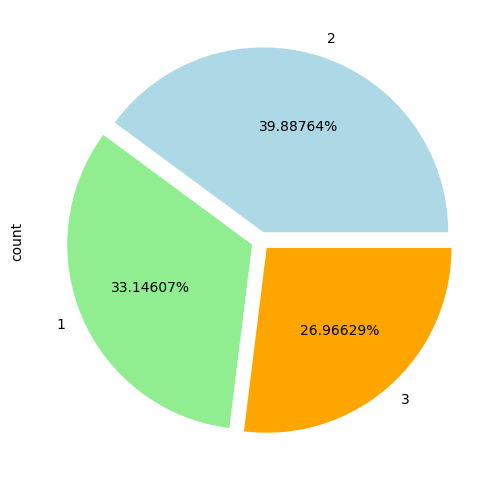

In [73]:
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 8
fig_size[1] = 6
plt.rcParams["figure.figsize"] = fig_size
data.Wine.value_counts().plot(kind='pie', autopct='%0.05f%%', colors=['lightblue', 'lightgreen', 'orange'], explode=(0.05, 0.05, 0.05))


In [74]:
data.columns

Index(['Wine', 'Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols',
       'Flavanoids', 'Nonflavanoid.phenols', 'Proanth', 'Color.int', 'Hue',
       'OD', 'Proline'],
      dtype='object')

In [75]:
X = data.drop('Wine', axis=1).values
y = data['Wine'].values - 1
# Wine 클래스가 1,2,3 → 0,1,2로 변환
# CrossEntropyLoss는 0-based 필요

In [76]:
# Standardize the data

scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [77]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape,

((142, 13), (36, 13), (142,), (36,))

In [78]:
# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.int64)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.int64)

In [79]:
# Create DataLoader
train_dataset = TensorDataset(X_train, y_train)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = TensorDataset(X_test, y_test)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [80]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([142, 13]),
 torch.Size([36, 13]),
 torch.Size([142]),
 torch.Size([36]))

In [81]:
class WineClassifierDense(nn.Module):
    def __init__(self):
        super(WineClassifierDense, self).__init__()
        self.fc1 = nn.Linear(13, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 3)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

model = WineClassifierDense()
print(model)

WineClassifierDense(
  (fc1): Linear(in_features=13, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=3, bias=True)
)


In [82]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [83]:
# Variables to store loss and accuracy
train_losses = []
test_accuracies = []

# Training loop
num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_dataloader:
        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Calculate average loss over an epoch
    train_losses.append(running_loss / len(train_dataloader))

    # Evaluate on test data
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_dataloader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    test_accuracies.append(accuracy)

    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {train_losses[-1]:.4f}, Accuracy: {accuracy:.2f}%")

print("Training complete.")

Epoch 1/20, Loss: 1.0734, Accuracy: 55.56%
Epoch 2/20, Loss: 1.0053, Accuracy: 86.11%
Epoch 3/20, Loss: 0.9277, Accuracy: 94.44%
Epoch 4/20, Loss: 0.8474, Accuracy: 94.44%
Epoch 5/20, Loss: 0.7616, Accuracy: 94.44%
Epoch 6/20, Loss: 0.6687, Accuracy: 94.44%
Epoch 7/20, Loss: 0.5790, Accuracy: 97.22%
Epoch 8/20, Loss: 0.5079, Accuracy: 97.22%
Epoch 9/20, Loss: 0.4167, Accuracy: 97.22%
Epoch 10/20, Loss: 0.3456, Accuracy: 97.22%
Epoch 11/20, Loss: 0.2925, Accuracy: 97.22%
Epoch 12/20, Loss: 0.2233, Accuracy: 100.00%
Epoch 13/20, Loss: 0.1843, Accuracy: 100.00%
Epoch 14/20, Loss: 0.1554, Accuracy: 100.00%
Epoch 15/20, Loss: 0.1351, Accuracy: 100.00%
Epoch 16/20, Loss: 0.1051, Accuracy: 100.00%
Epoch 17/20, Loss: 0.0905, Accuracy: 100.00%
Epoch 18/20, Loss: 0.0802, Accuracy: 100.00%
Epoch 19/20, Loss: 0.0725, Accuracy: 100.00%
Epoch 20/20, Loss: 0.0613, Accuracy: 100.00%
Training complete.


In [84]:
# Evaluation
model.eval()
all_labels = []
all_predictions = []
with torch.no_grad():
    for inputs, labels in test_dataloader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

# Convert to numpy arrays
all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

# Calculate metrics
conf_matrix = confusion_matrix(all_labels, all_predictions)
f1 = f1_score(all_labels, all_predictions, average='weighted')
precision = precision_score(all_labels, all_predictions, average='weighted')
recall = recall_score(all_labels, all_predictions, average='weighted')

# Calculate specificity for each class
specificity = []
for i in range(conf_matrix.shape[0]):
    tn = conf_matrix.sum() - (conf_matrix[i, :].sum() + conf_matrix[:, i].sum() - conf_matrix[i, i])
    fp = conf_matrix[:, i].sum() - conf_matrix[i, i]
    specificity.append(tn / (tn + fp))

print(f'Confusion Matrix:\n{conf_matrix}')
print(f'F1 Score: {f1:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'Specificity: {np.mean(specificity):.2f}')

Confusion Matrix:
[[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]
F1 Score: 1.00
Precision: 1.00
Recall: 1.00
Specificity: 1.00


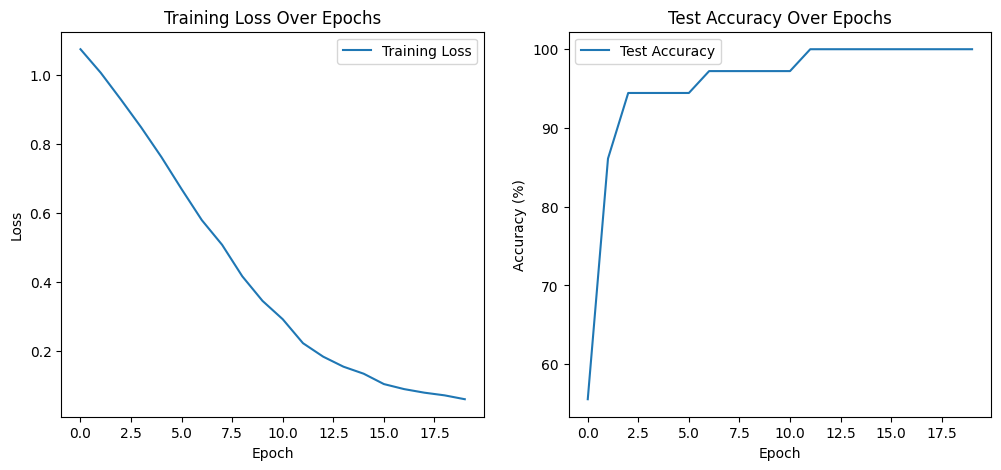

In [85]:
# Plot the loss and accuracy
plt.figure(figsize=(12, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Test Accuracy Over Epochs')
plt.legend()

plt.show()

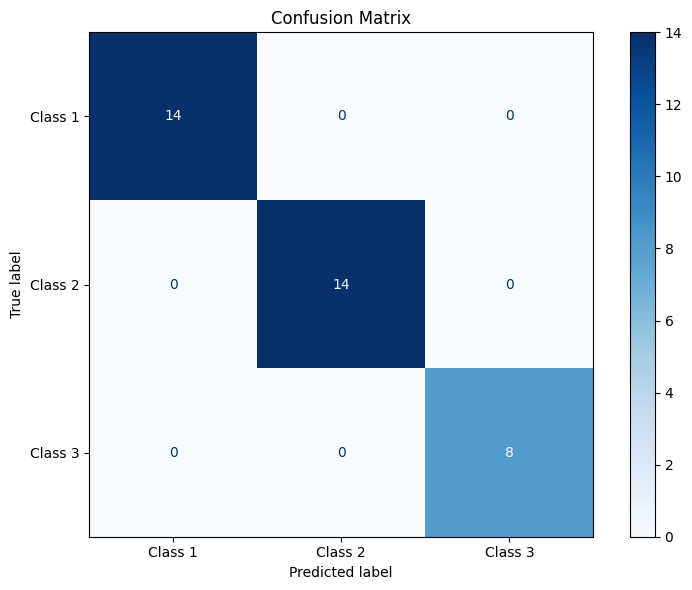

In [86]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix,
    display_labels=['Class 1', 'Class 2', 'Class 3']
)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [87]:
# ── 5-Fold Cross Validation ──────────────────────────────
from sklearn.model_selection import StratifiedKFold

def build_model():
    model = WineClassifierDense()
    return model

def train_one_fold(X_tr, y_tr, X_val, y_val, num_epochs=50):
    # fold 내부에서 스케일링 (데이터 누수 방지)
    sc = StandardScaler()
    X_tr  = sc.fit_transform(X_tr)
    X_val = sc.transform(X_val)

    X_tr_t  = torch.tensor(X_tr,  dtype=torch.float32)
    y_tr_t  = torch.tensor(y_tr,  dtype=torch.int64)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.int64)

    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=True)

    m    = build_model()
    crit = nn.CrossEntropyLoss()
    opt  = optim.Adam(m.parameters(), lr=0.001)

    fold_train_accs = []
    fold_val_accs   = []

    for epoch in range(num_epochs):
        m.train()
        for xb, yb in loader:
            opt.zero_grad()
            loss = crit(m(xb), yb)
            loss.backward()
            opt.step()

        m.eval()
        with torch.no_grad():
            tr_pred  = torch.argmax(m(X_tr_t),  dim=1)
            tr_acc   = (tr_pred == y_tr_t).float().mean().item() * 100
            val_pred = torch.argmax(m(X_val_t), dim=1)
            val_acc  = (val_pred == y_val_t).float().mean().item() * 100

        fold_train_accs.append(tr_acc)
        fold_val_accs.append(val_acc)

    m.eval()
    with torch.no_grad():
        preds = torch.argmax(m(X_val_t), dim=1).numpy()

    f1  = f1_score(y_val, preds, average='weighted')
    pre = precision_score(y_val, preds, average='weighted', zero_division=0)
    rec = recall_score(y_val, preds, average='weighted', zero_division=0)

    return f1, pre, rec, fold_train_accs, fold_val_accs

# ── 실행 ──
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_results     = []
all_train_curves = []
all_val_curves   = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    f1, pre, rec, tr_c, val_c = train_one_fold(
        X[tr_idx], y[tr_idx], X[val_idx], y[val_idx], num_epochs=50
    )
    fold_results.append({'fold': fold+1, 'F1': f1, 'Precision': pre, 'Recall': rec})
    all_train_curves.append(tr_c)
    all_val_curves.append(val_c)
    print(f"Fold {fold+1}  F1={f1:.4f}  Precision={pre:.4f}  Recall={rec:.4f}")

# 평균
f1_mean  = np.mean([r['F1'] for r in fold_results])
pre_mean = np.mean([r['Precision'] for r in fold_results])
rec_mean = np.mean([r['Recall'] for r in fold_results])
f1_std   = np.std([r['F1'] for r in fold_results])

print(f"\n{'='*45}")
print(f"  5-Fold 평균  F1={f1_mean:.4f} ± {f1_std:.4f}")
print(f"  Precision={pre_mean:.4f}  Recall={rec_mean:.4f}")
print(f"{'='*45}")

Fold 1  F1=0.9724  Precision=0.9747  Recall=0.9722
Fold 2  F1=1.0000  Precision=1.0000  Recall=1.0000
Fold 3  F1=0.9720  Precision=0.9741  Recall=0.9722
Fold 4  F1=1.0000  Precision=1.0000  Recall=1.0000
Fold 5  F1=1.0000  Precision=1.0000  Recall=1.0000

  5-Fold 평균  F1=0.9889 ± 0.0136
  Precision=0.9898  Recall=0.9889


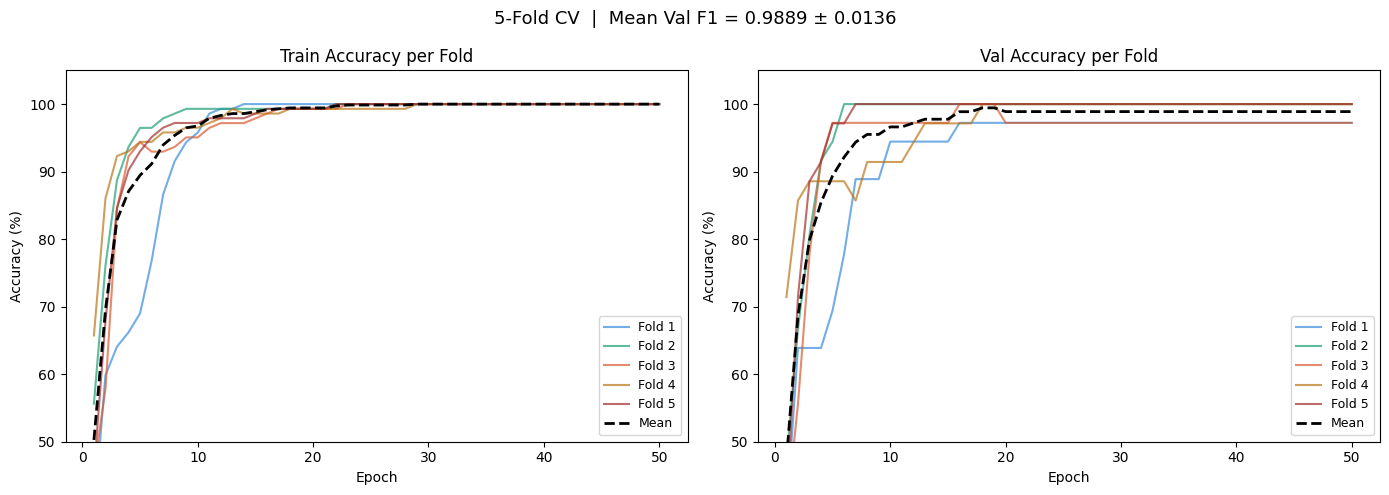

In [88]:
# ── Train vs Val Accuracy 곡선 (fold별) ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, 51)
colors = ['#378ADD', '#1D9E75', '#D85A30', '#BA7517', '#A32D2D']

for i, (tr_c, val_c) in enumerate(zip(all_train_curves, all_val_curves)):
    axes[0].plot(epochs_range, tr_c,  color=colors[i], alpha=0.7, label=f'Fold {i+1}')
    axes[1].plot(epochs_range, val_c, color=colors[i], alpha=0.7, label=f'Fold {i+1}')

axes[0].set_title('Train Accuracy per Fold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend(fontsize=9)
axes[0].set_ylim(50, 105)

axes[1].set_title('Val Accuracy per Fold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(fontsize=9)
axes[1].set_ylim(50, 105)

# fold 평균선
mean_train = np.mean(all_train_curves, axis=0)
mean_val   = np.mean(all_val_curves,   axis=0)
axes[0].plot(epochs_range, mean_train, 'k--', linewidth=2, label='Mean')
axes[1].plot(epochs_range, mean_val,   'k--', linewidth=2, label='Mean')
axes[0].legend(fontsize=9)
axes[1].legend(fontsize=9)

plt.suptitle(f'5-Fold CV  |  Mean Val F1 = {f1_mean:.4f} ± {f1_std:.4f}', fontsize=13)
plt.tight_layout()
plt.show()